## Feature Extraction
Feature extraction involves reusing the convolutional base of a pre-trained model (like VGG16) to extract meaningful patterns from images, while keeping these base layers frozen. Since the model was already trained on a large-scale dataset (like ImageNet), it acts as a fixed feature extractor.



In [80]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16
from keras.callbacks import EarlyStopping


In [81]:
conv_base = VGG16(
    include_top=False,
    weights="imagenet",
    input_shape=(150,150,3)
)

In [82]:
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

In [83]:
model =Sequential()
model.add(conv_base)
model.add(Flatten())
model.add(Dense(256, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

In [84]:
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten_4 (Flatten)         (None, 8192)              0         
                                                                 
 dense_8 (Dense)             (None, 256)               2097408   
                                                                 
 dense_9 (Dense)             (None, 1)                 257       
                                                                 
Total params: 16,812,353
Trainable params: 16,812,353
Non-trainable params: 0
_________________________________________________________________


In [85]:
conv_base.trainable = False

In [86]:
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten_4 (Flatten)         (None, 8192)              0         
                                                                 
 dense_8 (Dense)             (None, 256)               2097408   
                                                                 
 dense_9 (Dense)             (None, 1)                 257       
                                                                 
Total params: 16,812,353
Trainable params: 2,097,665
Non-trainable params: 14,714,688
_________________________________________________________________


In [87]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = r"C:\Users\rauna\codes\datasets\catsvsdogs\train",
    labels = "inferred",
    label_mode = 'int',
    batch_size = 32,
    image_size=(150,150)
)

Found 20000 files belonging to 2 classes.


In [88]:
validation_ds = keras.utils.image_dataset_from_directory(
    directory = r"C:\Users\rauna\codes\datasets\catsvsdogs\test",
    labels = "inferred",
    label_mode = 'int',
    batch_size = 32,
    image_size=(150,150)
)

Found 4998 files belonging to 2 classes.


In [89]:
# Normalize
def process(image,label):
    image = tensorflow.cast(image/255. ,tensorflow.float32)
    return image,label


train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [90]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [91]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    verbose=1,
    patience=0,
    restore_best_weights=True
)

In [92]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds, callbacks=callback)

Epoch 1/10


625/625 [==============================] - 90s 143ms/step - loss: 0.2800 - accuracy: 0.8796 - val_loss: 0.2579 - val_accuracy: 0.8866
Epoch 2/10
625/625 [==============================] - 90s 144ms/step - loss: 0.1891 - accuracy: 0.9202 - val_loss: 0.3205 - val_accuracy: 0.8517
Epoch 2: early stopping


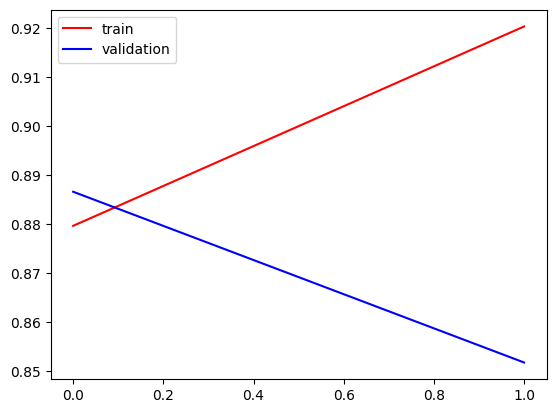

In [93]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

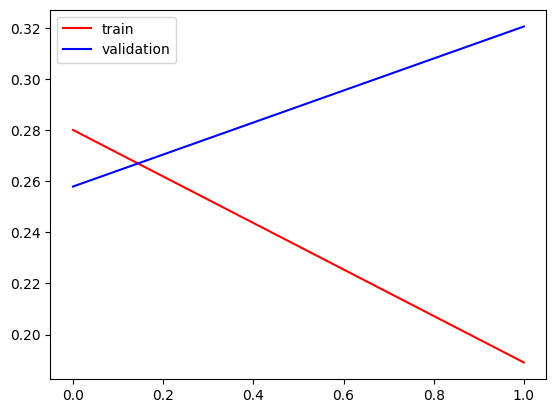

In [94]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

## Fine Tuning
Fine-tuning is a more advanced technique where, in addition to replacing the top layers, we unfreeze some of the later layers of the pre-trained convolutional base and re-train them alongside our custom classifier.

In [95]:
conv_base2 = VGG16(
    weights = "imagenet",
    include_top=False,
    input_shape=(150,150,3)
)

In [96]:
conv_base2.trainable = True

set_trainable = False

for layer in conv_base2.layers:
    if layer.name =="block5_conv1":
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False
        
        
for layer in conv_base2.layers:
    print(layer.name, layer.trainable)

input_5 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [97]:
conv_base2.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

In [98]:
model2 = Sequential()

model2.add(conv_base2)
model2.add(Flatten())
model2.add(Dense(256, activation="relu"))
model2.add(Dense(1,activation="sigmoid"))

In [99]:
train_ds = keras.utils.image_dataset_from_directory(
    directory=r"C:\Users\rauna\codes\datasets\catsvsdogs\train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(150,150))

validation_ds = keras.utils.image_dataset_from_directory(
    directory=r"C:\Users\rauna\codes\datasets\catsvsdogs\train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(150,150))

Found 20000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.


In [100]:
def process(image, label):
    image = tensorflow.cast(image/255, tensorflow.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds= validation_ds.map(process)

In [101]:
model2.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.00001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [102]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    verbose=1,
    patience=0
)

In [103]:
history = model2.fit(train_ds,epochs=10, validation_data=validation_ds, callbacks=callback)

Epoch 1/10
625/625 [==============================] - 155s 247ms/step - loss: 0.2299 - accuracy: 0.9032 - val_loss: 0.1311 - val_accuracy: 0.9506
Epoch 2/10
625/625 [==============================] - 154s 247ms/step - loss: 0.1304 - accuracy: 0.9484 - val_loss: 0.0875 - val_accuracy: 0.9705
Epoch 2: early stopping


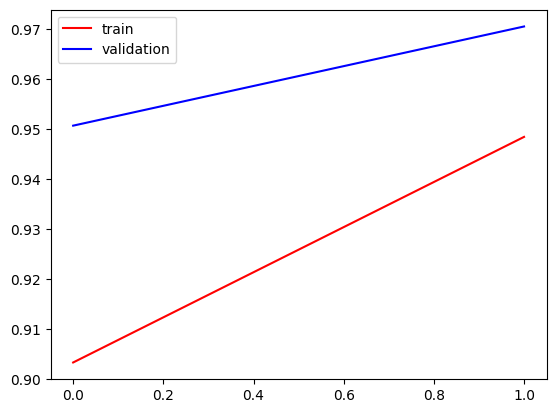

In [104]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

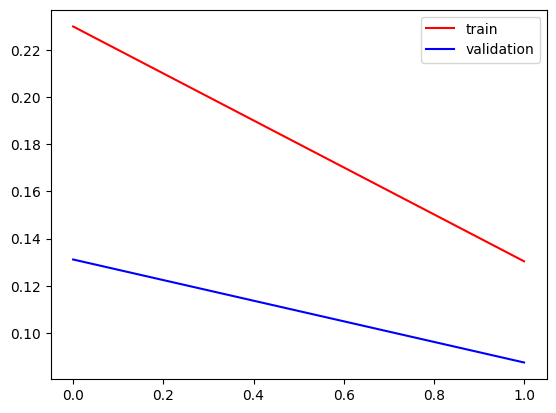

In [105]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()